# Code Testing Notebook

This notebook tests the various classes and functionalities of the psBQP (pseudo-spin Bogoliubov Quasiparticle) Keldysh implementation.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import sys

# Import our classes
from nambu_keldysh_class import NambuKeldyshTensor
from state_object_class import StateObject
from equilibrium_class import EquilibriumSolver
from usadel_keldysh_evolution import UsadelKeldyshEvolution

print("All imports successful!")

All imports successful!


In [2]:
def plot_nambu_components(nambu_tensor, time_grid, title="Nambu-Keldysh Tensor Components", 
                          vmin=None, vmax=None, cmap='RdBu_r'):
    """
    Plot all 4 Pauli components of a NambuKeldyshTensor in a 4x2 grid.
    
    Args:
        nambu_tensor: NambuKeldyshTensor with shape (2, 2, Nt, Nt)
                     component[i, j] represents g(t_i, t'_j)
        time_grid: Array of time values corresponding to the tensor indices
        title: Overall title for the figure
        vmin, vmax: Optional colorbar limits (if None, auto-scale per component)
        cmap: Colormap to use (default 'RdBu_r' for diverging red-blue)
    
    Layout:
        Top row: Real parts of [I, X, Y, Z] components
        Bottom row: Imaginary parts of [I, X, Y, Z] components
        
    Convention:
        After transpose, x-axis = t (first index), y-axis = t' (second index)
        Smallest times in top-left corner
    """
    pauli_labels = ['I (Identity)', 'X (σ_x)', 'Y (σ_y)', 'Z (σ_z)']
    
    # Create figure with 4 columns (Pauli components) x 2 rows (real/imag)
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    # Time extent for imshow (smallest times in top-left corner)
    # After transpose: x-axis is t, y-axis is t'
    t_min, t_max = time_grid[0], time_grid[-1]
    extent = [t_min, t_max, t_max, t_min]  # [left, right, bottom, top] with origin='upper'
    
    # Extract each Pauli component and plot
    for pauli_idx in range(4):
        # Extract Pauli component using trace (divide by 2 for normalization)
        component = nambu_tensor.trace(pauli_index=pauli_idx) / 2
        
        # Transpose: component[i,j] -> component.T[j,i]
        # So x-axis (columns) = i = t, y-axis (rows) = j = t'
        
        # Real part (top row)
        ax_real = axes[0, pauli_idx]
        im_real = ax_real.imshow(np.real(component).T, aspect='auto', origin='upper',
                                 extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax_real.set_title(f"{pauli_labels[pauli_idx]} - Real", fontsize=10)
        ax_real.set_ylabel("t'", fontsize=9)
        if pauli_idx == 0:
            ax_real.set_ylabel("t'", fontsize=11, fontweight='bold')
        plt.colorbar(im_real, ax=ax_real, fraction=0.046, pad=0.04)
        
        # Imaginary part (bottom row)
        ax_imag = axes[1, pauli_idx]
        im_imag = ax_imag.imshow(np.imag(component).T, aspect='auto', origin='upper',
                                 extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        ax_imag.set_title(f"{pauli_labels[pauli_idx]} - Imag", fontsize=10)
        ax_imag.set_xlabel("t", fontsize=11, fontweight='bold')
        ax_imag.set_ylabel("t'", fontsize=9)
        if pauli_idx == 0:
            ax_imag.set_ylabel("t'", fontsize=11, fontweight='bold')
        plt.colorbar(im_imag, ax=ax_imag, fraction=0.046, pad=0.04)
    
    # Overall title
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()

print("Plotting function defined: plot_nambu_components()")

Plotting function defined: plot_nambu_components()


---
## 1. NambuKeldyshTensor Class Tests <a name="nambu-keldysh-tensor"></a>

Test basic operations of the NambuKeldyshTensor class.

### 1.1 Creation and Initialization

In [7]:
# Test creating NambuKeldyshTensor with different Pauli indices
print("Testing NambuKeldyshTensor creation:")

# Create simple test data
test_data = np.array([1.0, 1.0 + 1j, 1.0j], dtype=complex)

a_data = np.array([[1,2,3],[4,5,6],[7,8,9]])
b_data = a_data.T
# Create tensors with different Pauli indices
Amatrix = NambuKeldyshTensor(a_data, pauli_channel=1)
v1 = NambuKeldyshTensor(test_data, pauli_channel=3)
v2 = NambuKeldyshTensor(test_data.T, pauli_channel=3)
tau_3 = NambuKeldyshTensor(1, pauli_channel=3)
scalar = 1j

print('Amatrix')
print(Amatrix)
print('v1')
print(v1)
print('tau_3')
print(tau_3)
print('scalar')
print(scalar)



Testing NambuKeldyshTensor creation:
Amatrix
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 2.+0.j  4.+0.j  6.+0.j]
 [ 8.+0.j 10.+0.j 12.+0.j]
 [14.+0.j 16.+0.j 18.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 

v1
Id Trace: [0.+0.j 0.+0.j 0.+0.j] 
 X Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Y Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Z Trace: [2.+0.j 2.+2.j 0.+2.j] 

tau_3
Id Trace: 0j 
 X Trace: 0j 
 Y Trace: 0j 
 Z Trace: (2+0j) 

scalar
1j


### 1.2 Simple operations, addition, subtraction etc

In [8]:
# Test addition and scalar multiplication
print('tau_3 + tau_3')
print(tau_3 + tau_3)
print('v1 + v1')
print(v1 + v1)
print('Amatrix + Amatrix')
print(Amatrix + Amatrix)


tau_3 + tau_3
Id Trace: 0j 
 X Trace: 0j 
 Y Trace: 0j 
 Z Trace: (4+0j) 

v1 + v1
Id Trace: [0.+0.j 0.+0.j 0.+0.j] 
 X Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Y Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Z Trace: [4.+0.j 4.+4.j 0.+4.j] 

Amatrix + Amatrix
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 4.+0.j  8.+0.j 12.+0.j]
 [16.+0.j 20.+0.j 24.+0.j]
 [28.+0.j 32.+0.j 36.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 



### 1.3 Mutliplication possiblities

In [9]:
# Test addition and scalar multiplication

print('Same shape multiplication')
print('tau_3 * tau_3')
print(tau_3 * tau_3)
print('v1 * v1')
print(v1 * v1)
print('Amatrix * Amatrix')
print(Amatrix * Amatrix)

print('Scalar multiplication')
print('scalar * tau_3')
print(scalar * tau_3)
print('scalar * v1')
print(scalar * v1)
print('scalar * Amatrix')
print(scalar * Amatrix)
print('Different shape multiplication')

print('tau_3 * Amatrix')
print(tau_3 * Amatrix)
print('Amatrix * tau_3')
print(Amatrix * tau_3)
print('v1 * Amatrix')
print(v1 * Amatrix)
print('Amatrix * v1')
print(Amatrix * v1)


Same shape multiplication
tau_3 * tau_3
Id Trace: (2+0j) 
 X Trace: 0j 
 Y Trace: 0j 
 Z Trace: 0j 

v1 * v1
Id Trace: [ 2.+0.j  0.+4.j -2.+0.j] 
 X Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Y Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Z Trace: [0.+0.j 0.+0.j 0.+0.j] 

Amatrix * Amatrix
Id Trace: [[  2.+0.j   8.+0.j  18.+0.j]
 [ 32.+0.j  50.+0.j  72.+0.j]
 [ 98.+0.j 128.+0.j 162.+0.j]] 
 X Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 

Scalar multiplication
scalar * tau_3
Id Trace: 0j 
 X Trace: 0j 
 Y Trace: 0j 
 Z Trace: 2j 

scalar * v1
Id Trace: [0.+0.j 0.+0.j 0.+0.j] 
 X Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Y Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Z Trace: [ 0.+2.j -2.+2.j -2.+0.j] 

scalar * Amatrix
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[0. +2.j 0. +4.j 0. 

### 1.4 Matrix Multiplication (@)

In [10]:
print('A conv A')
print(Amatrix @ Amatrix)


A conv A
Id Trace: [[ 60.+0.j  72.+0.j  84.+0.j]
 [132.+0.j 162.+0.j 192.+0.j]
 [204.+0.j 252.+0.j 300.+0.j]] 
 X Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 



### 1.5 Involution and related operations

In [11]:
print('A transpose')
print(Amatrix.transpose())
print('A complete transpose')
print(Amatrix.complete_transpose())
print('A dagger')
print(Amatrix.conj().transpose())
print('A involution')
print(Amatrix.involution())

A transpose
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 2.+0.j  4.+0.j  6.+0.j]
 [ 8.+0.j 10.+0.j 12.+0.j]
 [14.+0.j 16.+0.j 18.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 

A complete transpose
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 2.+0.j  8.+0.j 14.+0.j]
 [ 4.+0.j 10.+0.j 16.+0.j]
 [ 6.+0.j 12.+0.j 18.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 

A dagger
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 2.+0.j  4.+0.j  6.+0.j]
 [ 8.+0.j 10.+0.j 12.+0.j]
 [14.+0.j 16.+0.j 18.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Tr

### 1.6 Test plotting function

Testing plot_nambu_components() with simple 3x3 matrix:


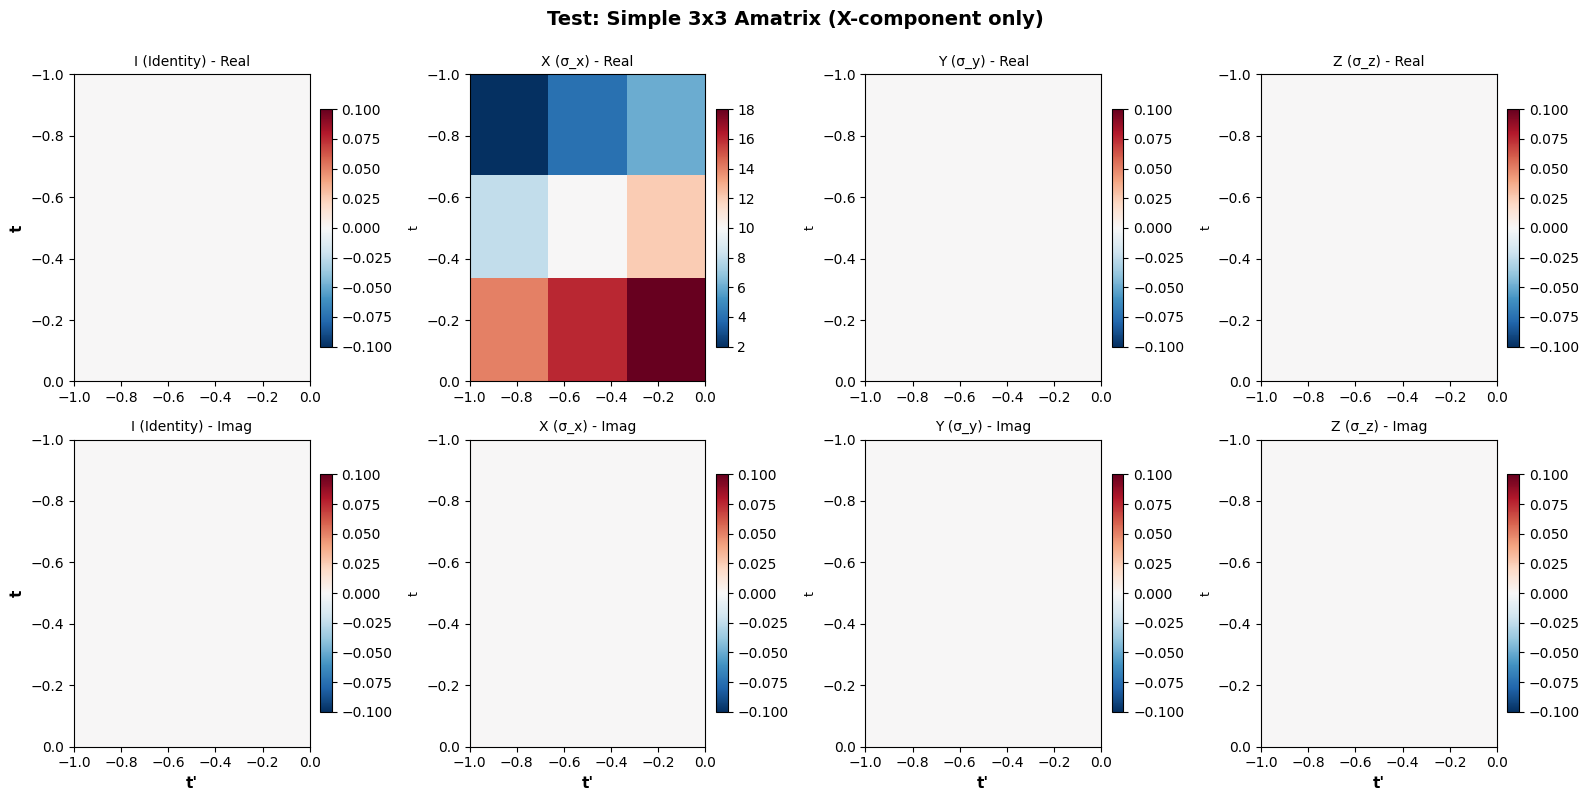

In [16]:
# Test the plotting function with the Amatrix we created earlier
# Create a simple time grid for the 3x3 test matrix
test_time_grid = np.linspace(-1, 0, 3)

print("Testing plot_nambu_components() with simple 3x3 matrix:")
plot_nambu_components(Amatrix, test_time_grid, 
                     title="Test: Simple 3x3 Amatrix (X-component only)")

### 1.7 Test update method

In [17]:
Amatrix = NambuKeldyshTensor(a_data, pauli_channel=1)
print(v1)
print('Old A matrix')
print(Amatrix)
Amatrix.update_entries(v1 ,2*v2 * 0,tau_3 * 7)
print('New A matrix')
print(Amatrix)

Id Trace: [0.+0.j 0.+0.j 0.+0.j] 
 X Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Y Trace: [0.+0.j 0.+0.j 0.+0.j] 
 Z Trace: [2.+0.j 2.+2.j 0.+2.j] 

Old A matrix
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[ 2.+0.j  4.+0.j  6.+0.j]
 [ 8.+0.j 10.+0.j 12.+0.j]
 [14.+0.j 16.+0.j 18.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 

New A matrix
Id Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 X Trace: [[10.+0.j 12.+0.j  0.+0.j]
 [16.+0.j 18.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j]] 
 Y Trace: [[0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j]] 
 Z Trace: [[ 0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j]
 [ 2.+2.j  0.+2.j 14.+0.j]] 



### Conclusion:

- Nambu class operations work as expected
- Other algebraic features work, including the update method

---
## 2. Equilibrium Generation Test <a name="equilibrium-generation"></a>

Test generating equilibrium initial state.

### 2.1 Create Evolution Object and Generate Initial State

### 2.1 Visualize Equilibrium Green's Functions with New Plotting Function

In [14]:
print("Testing equilibrium initial state generation:")
print()

# Define grid parameters
grid_parameters = {
    'time_sampling': 1500,
    'time_duration': 2* np.pi * 5,
    'eta': 0.1
}

# Define system parameters
system_parameters = {
    'critical_temperature': 1.0,
    'temperature': 0.3,
    'eta': 0.1

}

# Create evolution object
evolution = UsadelKeldyshEvolution(grid_parameters, system_parameters)
print(f"Evolution object created")
print(f"  Time grid: {evolution.ntpoints} points from {evolution.time_grid[0]:.2f} to {evolution.time_grid[-1]:.2f}")
print(f"  BCS coupling: {evolution._get_BCS_coupling():.4f}")
print()

# Generate initial equilibrium state
print("Generating initial equilibrium state...")
initial_state = evolution.generate_initial_state(Q=0.0)
print(f"Initial state generated")
print(f"  g^R shape: {initial_state.gr.data.shape}")
print(f"  g^K shape: {initial_state.gk.data.shape}")
print()

# Extract gap from initial state
gap_history = initial_state.get_gap_history()
print(f"Gap values:")
print(f"  Mean: {np.mean(np.abs(gap_history)):.4f}")
print(f"  Std: {np.std(np.abs(gap_history)):.4f}")
print(f"  First value: {gap_history[0]:.4f}")
print(f"  Last value: {gap_history[-1]:.4f}")


Testing equilibrium initial state generation:

[-149.85001667 -149.75005002 -149.65008336 ...  149.65008336  149.75005002
  149.85001667]
         Recommended: eta >= 10/T_max = 10/31.42
         Consider using larger T_max or increasing eta to avoid numerical issues.
Evolution object created
  Time grid: 1500 points from -31.42 to 0.00
  BCS coupling: 1.2235

Generating initial equilibrium state...
Equilibrium gap is: 1.6456255
Initial state generated
  g^R shape: (2, 2, 1500, 1500)
  g^K shape: (2, 2, 1500, 1500)

Gap values:
  Mean: 1.6458
  Std: 0.0000
  First value: 1.6458-0.0000j
  Last value: 1.6458-0.0000j


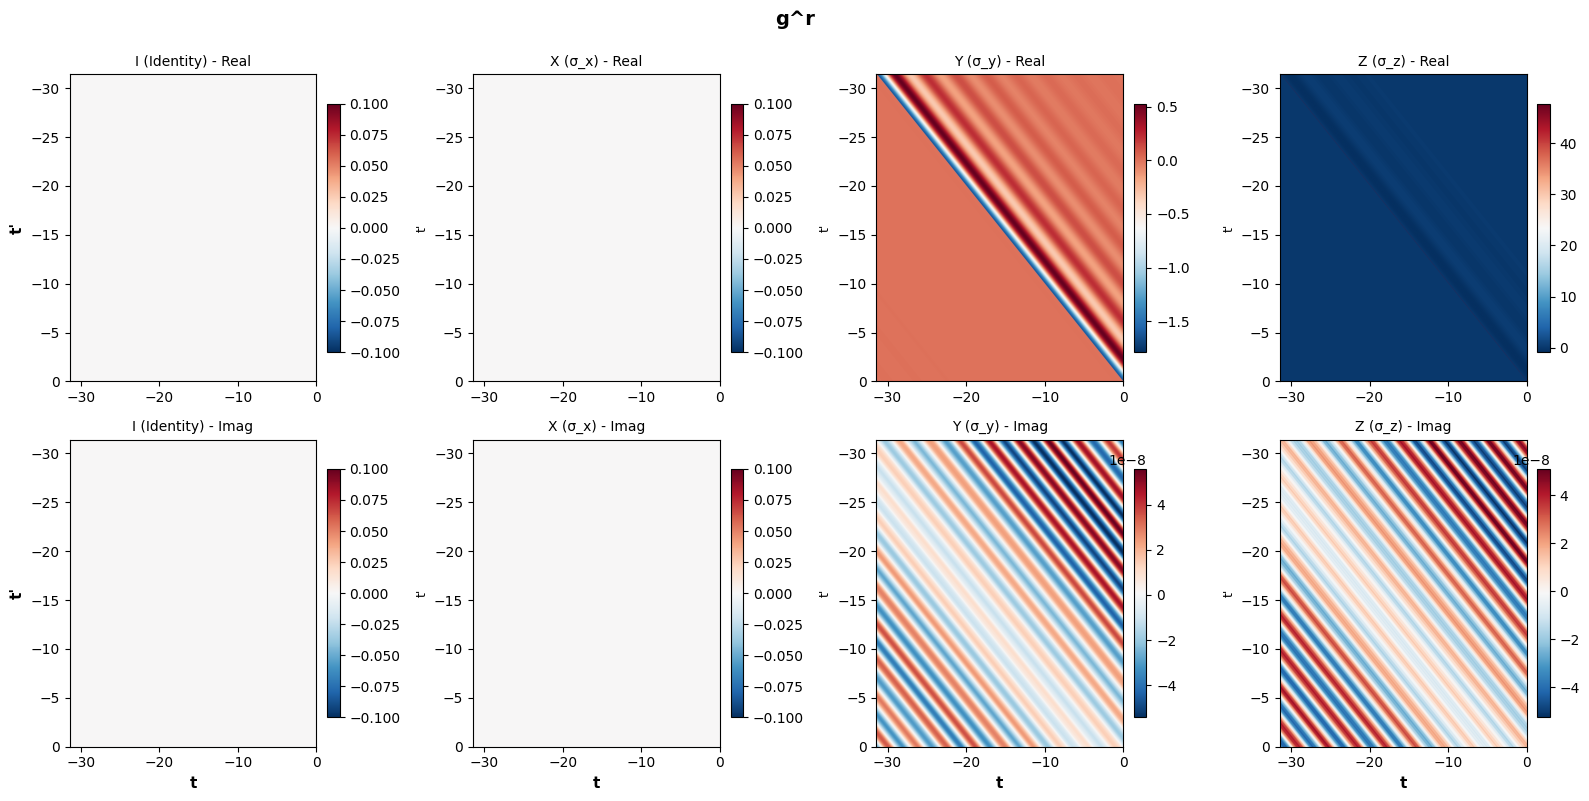

(0.29472577571868896+2.2467725457886445e-09j)
(-3.578066825866699-1.2179714181659307e-10j)


In [16]:
plot_nambu_components(initial_state.gr, evolution.time_grid, 'g^r')
print(initial_state.gr.trace(2)[0,1])
print(initial_state.gr.trace(2)[1,0])

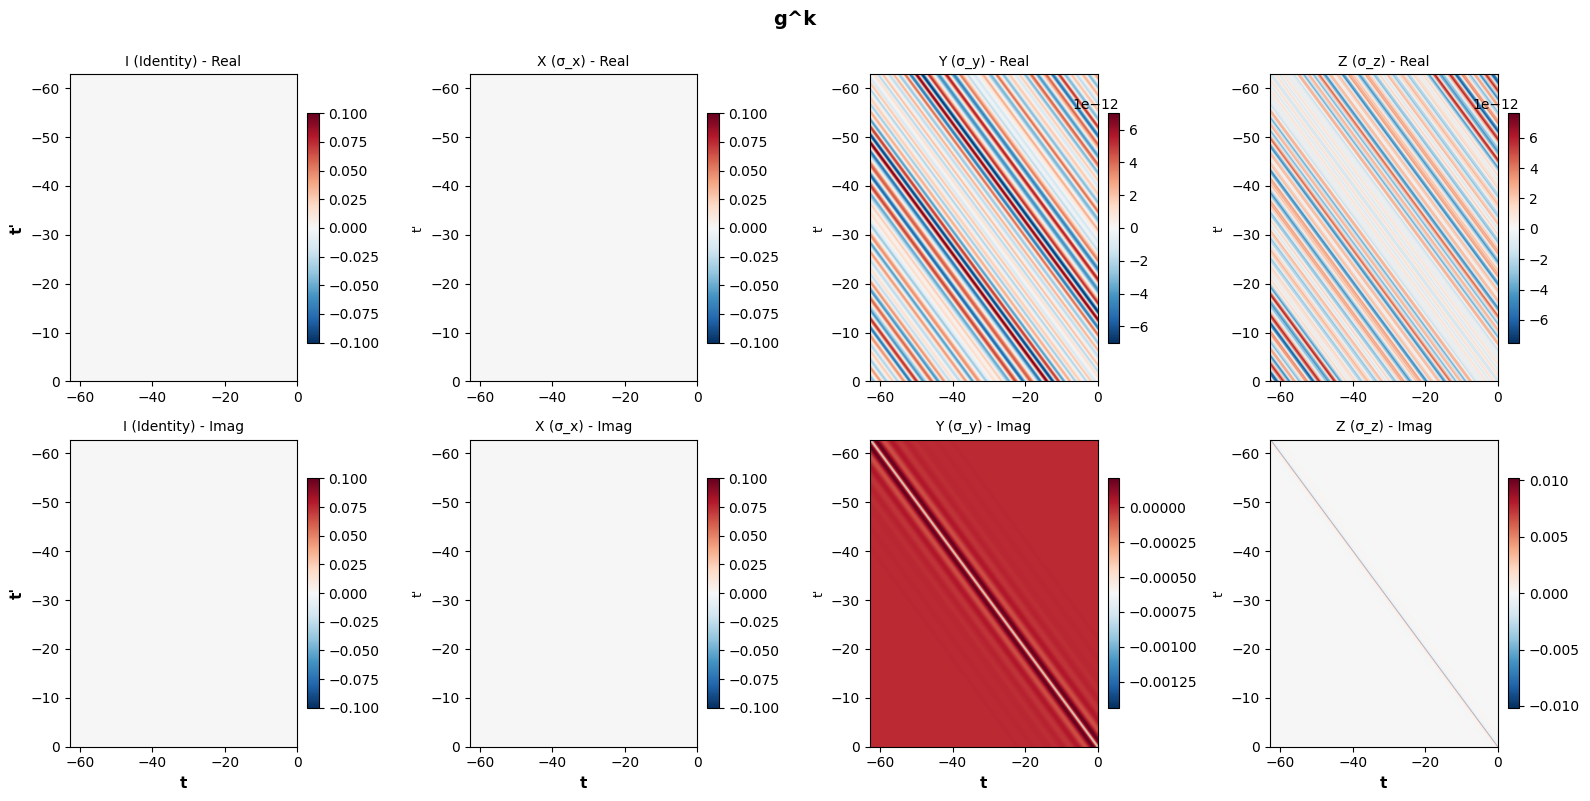

In [5]:
plot_nambu_components(initial_state.gk, evolution.time_grid, 'g^k')